In [113]:

print("installing  packages")


%pip install optuna  # Bayesian optimization
%pip install imbalanced-learn  # SMOTE and sampling techniques
%pip install tqdm



installing  packages
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]2m1/2 [optuna]


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import networkx as nx
from gensim.models import KeyedVectors

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_selection import SelectKBest, f_classif, RFE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    make_scorer
)

from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna
from scipy.stats import uniform, randint

from tqdm.notebook import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")
print(f"   NumPy version: {np.__version__}")
print(f"   Pandas version: {pd.__version__}")
print(f"   Optuna version: {optuna.__version__}")

✅ All libraries imported successfully!
   NumPy version: 1.26.4
   Pandas version: 2.2.2
   Optuna version: 4.6.0


In [121]:
# ============================================================================
# SECTION 3: UPLOAD FILES FROM VS CODE TO COLAB KERNEL
# ============================================================================

print("\n" + "=" * 80)
print("📤 UPLOAD FILES FROM VS CODE TO COLAB KERNEL")
print("=" * 80)

print("""
📁 REQUIRED FILES TO UPLOAD (13 files):
----------------------------------------
1. best_classifier.pkl       (Trained Logistic Regression pipeline)
2. node2vec_model.wv          (Node2Vec embeddings model)
3. X_embeddings.npy           (Full embedding matrix)
4. y_labels.npy               (Department labels)
5. node_ids.npy               (Node tracking IDs)
6. X_train.npy                (Training features)
7. X_val.npy                  (Validation features)
8. X_test.npy                 (Test features)
9. y_train.npy                (Training labels)
10. y_val.npy                 (Validation labels)
11. y_test.npy                (Test labels)
12. metadata.json             (Training metadata)
13. model_comparison.csv      (Model performance comparison)

📋 UPLOAD INSTRUCTIONS IN VS CODE:
-----------------------------------
1. Look at the LEFT SIDEBAR in VS Code
2. Find the "REMOTE EXPLORER" or "FILES" section
3. You should see a "Upload Files" button or right-click menu option
4. Select all 13 files from:
   c:\\Users\\Dell\\Desktop\\Dev\\AI-projects\\email-eu-graph-platform\\models\\
5. Files will upload directly to Colab kernel's /content/ directory
6. Wait for upload to complete (check status bar)
7. Run the next cell to verify

⚠️  ALTERNATIVE METHOD (if above doesn't work):
------------------------------------------------
Use the IPython display widget to upload files:
""")

# Create upload widget for VS Code
from IPython.display import display
from ipywidgets import FileUpload

print("\n📤 File Upload Widget:")
print("   Click 'Upload' button below to select files")
print("   You can select multiple files at once (Ctrl+Click)")
print("=" * 80)

# Create file upload widget
uploader = FileUpload(accept='*', multiple=True)
display(uploader)

print("\n⏳ After uploading, run the cell below to save files to /content/")


📤 UPLOAD FILES FROM VS CODE TO COLAB KERNEL

📁 REQUIRED FILES TO UPLOAD (13 files):
----------------------------------------
1. best_classifier.pkl       (Trained Logistic Regression pipeline)
2. node2vec_model.wv          (Node2Vec embeddings model)
3. X_embeddings.npy           (Full embedding matrix)
4. y_labels.npy               (Department labels)
5. node_ids.npy               (Node tracking IDs)
6. X_train.npy                (Training features)
7. X_val.npy                  (Validation features)
8. X_test.npy                 (Test features)
9. y_train.npy                (Training labels)
10. y_val.npy                 (Validation labels)
11. y_test.npy                (Test labels)
12. metadata.json             (Training metadata)
13. model_comparison.csv      (Model performance comparison)

📋 UPLOAD INSTRUCTIONS IN VS CODE:
-----------------------------------
1. Look at the LEFT SIDEBAR in VS Code
2. Find the "REMOTE EXPLORER" or "FILES" section
3. You should see a "Upload Files"

FileUpload(value={}, accept='*', description='Upload', multiple=True)


⏳ After uploading, run the cell below to save files to /content/


In [122]:
# ============================================================================
# SECTION 4: SAVE UPLOADED FILES TO COLAB /content/ DIRECTORY
# ============================================================================

print("\n" + "=" * 80)
print("💾 SAVING UPLOADED FILES TO COLAB")
print("=" * 80)

# Save uploaded files from widget to /content/
uploaded_files = uploader.value

if len(uploaded_files) == 0:
    print("⚠️  No files uploaded yet!")
    print("   Please run the previous cell and upload files")
else:
    print(f"\n📦 Processing {len(uploaded_files)} uploaded files...\n")
    
    for filename, file_info in uploaded_files.items():
        file_path = os.path.join('/content/', filename)
        
        # Write file to /content/
        with open(file_path, 'wb') as f:
            f.write(file_info['content'])
        
        size_kb = len(file_info['content']) / 1024
        if size_kb > 1024:
            size_str = f"{size_kb/1024:.2f} MB"
        else:
            size_str = f"{size_kb:.1f} KB"
        
        print(f"   ✅ Saved: {filename:<30} {size_str:>10}")
    
    print(f"\n✅ All {len(uploaded_files)} files saved to /content/")
    print("=" * 80)


💾 SAVING UPLOADED FILES TO COLAB

📦 Processing 13 uploaded files...

   ✅ Saved: best_classifier.pkl               44.7 KB
   ✅ Saved: metadata.json                      3.3 KB
   ✅ Saved: model_comparison.csv               0.3 KB
   ✅ Saved: node_ids.npy                      15.5 KB
   ✅ Saved: node2vec_model.wv                517.0 KB
   ✅ Saved: X_embeddings.npy                 492.1 KB
   ✅ Saved: X_test.npy                        74.1 KB
   ✅ Saved: X_train.npy                      344.1 KB
   ✅ Saved: X_val.npy                         74.1 KB
   ✅ Saved: y_labels.npy                       7.8 KB
   ✅ Saved: y_test.npy                         1.3 KB
   ✅ Saved: y_train.npy                        5.5 KB
   ✅ Saved: y_val.npy                          1.3 KB

✅ All 13 files saved to /content/


In [123]:
# ============================================================================
# SECTION 5: LOAD TRAINED MODELS & DATA
# ============================================================================

print("\n" + "=" * 80)
print("📥 LOADING TRAINED MODELS & DATA")
print("=" * 80)

# Load best classifier (Logistic Regression pipeline)
print("\n🔷 Loading best classifier...")
with open('best_classifier.pkl', 'rb') as f:
    best_classifier = pickle.load(f)
print("   ✅ Loaded: best_classifier.pkl")

# Load Node2Vec model
print("\n🔷 Loading Node2Vec model...")
node2vec_model = KeyedVectors.load('node2vec_model.wv')
print(f"   ✅ Loaded: node2vec_model.wv")
print(f"   📊 Vocabulary size: {len(node2vec_model.index_to_key):,}")
print(f"   📊 Embedding dimension: {node2vec_model.vector_size}")

# Load embeddings and labels
print("\n🔷 Loading embeddings and labels...")
X = np.load('X_embeddings.npy')
y = np.load('y_labels.npy')
node_ids = np.load('node_ids.npy', allow_pickle=True)
print(f"   ✅ X shape: {X.shape}")
print(f"   ✅ y shape: {y.shape}")
print(f"   ✅ Node IDs: {len(node_ids):,}")

# Load train/val/test splits
print("\n🔷 Loading train/val/test splits...")
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

print(f"   ✅ Train set: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   ✅ Val set:   {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   ✅ Test set:  {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

# Load metadata
print("\n🔷 Loading metadata...")
with open('metadata.json', 'r') as f:
    metadata = json.load(f)
print(f"   ✅ Training date: {metadata['training_date']}")
print(f"   ✅ Best model: {metadata['best_model']['name']}")
print(f"   ✅ Test accuracy: {metadata['best_model']['test_accuracy']:.4f}")

# Load model comparison
print("\n🔷 Loading model comparison...")
model_comparison = pd.read_csv('model_comparison.csv')
print("   ✅ Model comparison loaded")
print("\n" + model_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("✅ ALL DATA LOADED SUCCESSFULLY!")
print("=" * 80)


📥 LOADING TRAINED MODELS & DATA

🔷 Loading best classifier...
   ✅ Loaded: best_classifier.pkl

🔷 Loading Node2Vec model...
   ✅ Loaded: node2vec_model.wv
   📊 Vocabulary size: 984
   📊 Embedding dimension: 128

🔷 Loading embeddings and labels...
   ✅ X shape: (984, 128)
   ✅ y shape: (984,)
   ✅ Node IDs: 984

🔷 Loading train/val/test splits...
   ✅ Train set: (688, 128) (69.9%)
   ✅ Val set:   (148, 128) (15.0%)
   ✅ Test set:  (148, 128) (15.0%)

🔷 Loading metadata...
   ✅ Training date: 2025-12-17 14:40:01
   ✅ Best model: Logistic Regression
   ✅ Test accuracy: 0.7703

🔷 Loading model comparison...
   ✅ Model comparison loaded

              Model  Train Acc  Val Acc  Test Acc  Test Precision  Test Recall  Test F1
Logistic Regression     1.0000   0.7432    0.7703          0.7624       0.7703   0.7556
      Random Forest     1.0000   0.6351    0.7095          0.6656       0.7095   0.6643
                SVM     0.9724   0.7230    0.7500          0.7854       0.7500   0.7462
  Grad


📊 BASELINE PERFORMANCE EVALUATION

🔍 Evaluating current best classifier on test set...

📈 BASELINE METRICS (Test Set)
Accuracy:  0.7703
Precision: 0.7624
Recall:    0.7703
F1-Score:  0.7556

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.67      0.80      0.73        10
           2       0.67      1.00      0.80         2
           3       1.00      0.50      0.67         2
           4       0.76      0.81      0.79        16
           5       0.67      1.00      0.80         2
           6       0.00      0.00      0.00         3
           7       0.83      0.62      0.71         8
           8       0.75      1.00      0.86         6
           9       0.75      0.60      0.67         5
          10       1.00      1.00      1.00         4
          11       0.89      1.00      0.94         8
          13       1.00      0.83      0.91         6
          14     

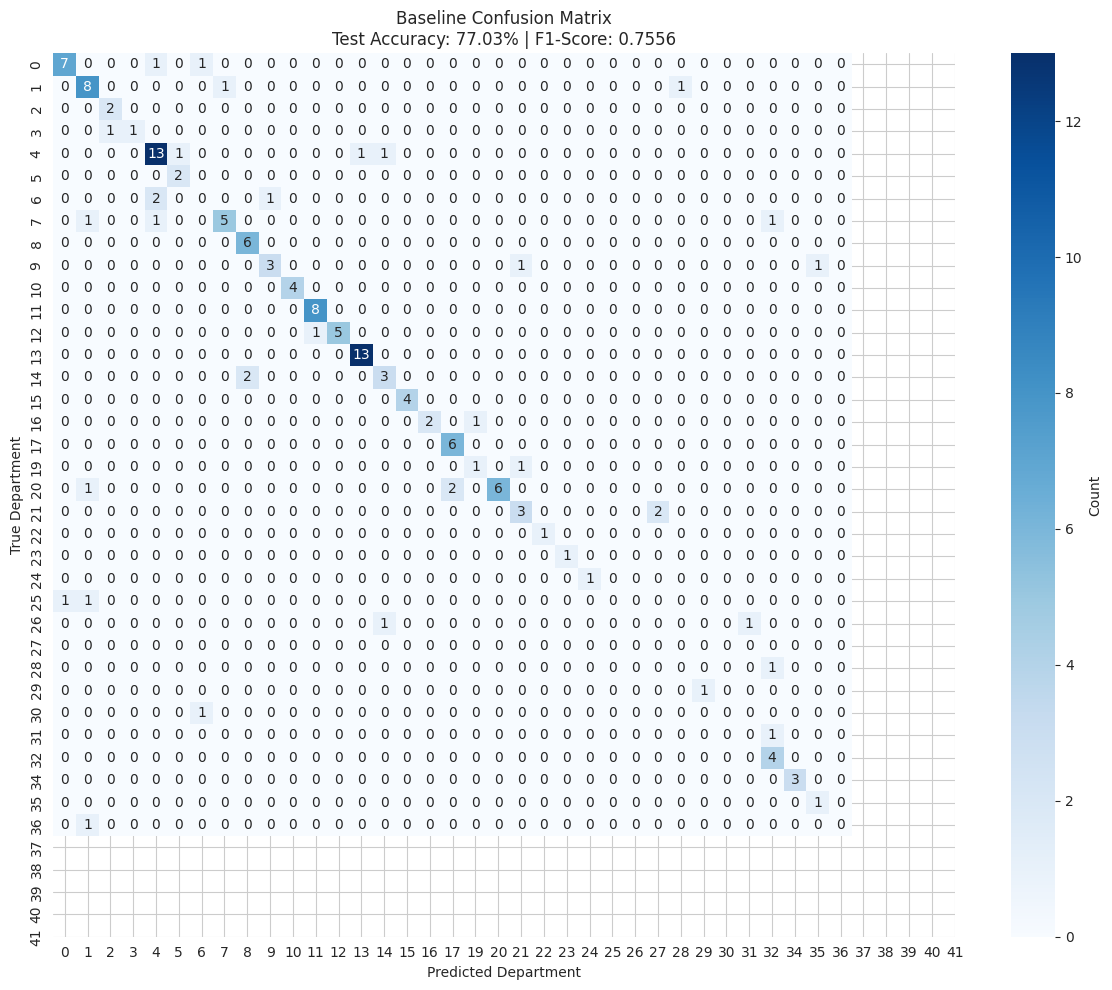


📊 Per-Class F1-Scores:


ValueError: All arrays must be of the same length

In [124]:
# ============================================================================
# SECTION 6: BASELINE PERFORMANCE EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("📊 BASELINE PERFORMANCE EVALUATION")
print("=" * 80)

# Evaluate current best classifier on test set
print("\n🔍 Evaluating current best classifier on test set...")

y_test_pred = best_classifier.predict(X_test)
y_test_proba = best_classifier.predict_proba(X_test) if hasattr(best_classifier, 'predict_proba') else None

# Calculate metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted', zero_division=0
)

print("\n" + "=" * 50)
print("📈 BASELINE METRICS (Test Set)")
print("=" * 50)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print("=" * 50)

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Confusion matrix
print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), 
            yticklabels=np.unique(y),
            cbar_kws={'label': 'Count'})
plt.title(f'Baseline Confusion Matrix\nTest Accuracy: {test_acc:.2%} | F1-Score: {test_f1:.4f}')
plt.ylabel('True Department')
plt.xlabel('Predicted Department')
plt.tight_layout()
plt.show()

# Per-class F1 scores
print("\n📊 Per-Class F1-Scores:")
per_class_f1 = f1_score(y_test, y_test_pred, average=None, zero_division=0)
class_f1_df = pd.DataFrame({
    'Department': np.unique(y),
    'F1-Score': per_class_f1,
    'Samples': [sum(y_test == dept) for dept in np.unique(y)]
}).sort_values('F1-Score', ascending=False)

print(class_f1_df.to_string(index=False))

# Identify worst-performing classes
worst_classes = class_f1_df.nsmallest(5, 'F1-Score')
print("\n⚠️  Top 5 Worst-Performing Departments:")
print(worst_classes.to_string(index=False))

# Store baseline for comparison
baseline_metrics = {
    'accuracy': test_acc,
    'precision': test_precision,
    'recall': test_recall,
    'f1_score': test_f1,
    'per_class_f1': per_class_f1.tolist(),
    'confusion_matrix': cm.tolist()
}

print("\n✅ Baseline evaluation complete!")
print("=" * 80)

In [125]:
# ============================================================================
# SECTION 7: DATA QUALITY CHECKS
# ============================================================================

print("\n" + "=" * 80)
print("🔍 DATA QUALITY CHECKS")
print("=" * 80)

print("\n📊 Dataset Statistics:")
print(f"   Total samples: {len(X):,}")
print(f"   Embedding dimension: {X.shape[1]}")
print(f"   Number of departments: {len(np.unique(y))}")
print(f"   Departments: {sorted(np.unique(y))}")

print("\n📊 Class Distribution:")
unique, counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({
    'Department': unique,
    'Count': counts,
    'Percentage': counts / len(y) * 100,
    'Train': [sum(y_train == dept) for dept in unique],
    'Val': [sum(y_val == dept) for dept in unique],
    'Test': [sum(y_test == dept) for dept in unique]
}).sort_values('Count', ascending=False)

print(class_dist.to_string(index=False))

print("\n📊 Data Quality Metrics:")
print(f"   NaN values: {np.isnan(X).sum():,}")
print(f"   Inf values: {np.isinf(X).sum():,}")
print(f"   Min value: {X.min():.4f}")
print(f"   Max value: {X.max():.4f}")
print(f"   Mean: {X.mean():.4f}")
print(f"   Std: {X.std():.4f}")

print("\n📊 Class Imbalance Ratio:")
imbalance_ratio = counts.max() / counts.min()
print(f"   Largest/Smallest class: {imbalance_ratio:.2f}x")

if imbalance_ratio > 3:
    print("   ⚠️  HIGH CLASS IMBALANCE DETECTED!")
    print("   → Consider SMOTE, class weights, or sampling techniques")
else:
    print("   ✅ Class distribution is relatively balanced")

print("\n✅ Data quality checks complete!")
print("=" * 80)


🔍 DATA QUALITY CHECKS

📊 Dataset Statistics:
   Total samples: 984
   Embedding dimension: 128
   Number of departments: 40
   Departments: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41]

📊 Class Distribution:
 Department  Count  Percentage  Train  Val  Test
          4    107     10.8740     75   16    16
         14     91      9.2480     64   14    13
          1     62      6.3008     43    9    10
         21     56      5.6911     39    8     9
         15     54      5.4878     38   11     5
          7     49      4.9797     34    7     8
          0     49      4.9797     34    6     9
         10     39      3.9634     27    8     4
         17     34      3.4553     24    7     3
          9     31      3.1504     22    4     5
         11     29      2.9472     20    1     8
         19     29      2.9472     20    3     6
          6     28      2.8455     20    5     3

In [126]:
# ============================================================================
# SECTION 8: HELPER FUNCTIONS
# ============================================================================

print("\n" + "=" * 80)
print("🛠️  DEFINING HELPER FUNCTIONS")
print("=" * 80)

def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name="Model"):
    """
    Comprehensive model evaluation on train, val, and test sets.
    """
    results = {}
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
    
    # Validation predictions
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
        y_test, y_test_pred, average='weighted', zero_division=0
    )
    
    results = {
        'model_name': model_name,
        'train_acc': train_acc,
        'train_f1': train_f1,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'test_acc': test_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1
    }
    
    print(f"\n{'='*60}")
    print(f"📊 {model_name} Performance")
    print(f"{'='*60}")
    print(f"{'Metric':<15} {'Train':<12} {'Validation':<12} {'Test':<12}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<15} {train_acc:>11.4f} {val_acc:>11.4f} {test_acc:>11.4f}")
    print(f"{'F1-Score':<15} {train_f1:>11.4f} {val_f1:>11.4f} {test_f1:>11.4f}")
    print(f"{'Precision':<15} {'':>11} {'':>11} {test_precision:>11.4f}")
    print(f"{'Recall':<15} {'':>11} {'':>11} {test_recall:>11.4f}")
    print(f"{'='*60}")
    
    return results, y_test_pred


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", figsize=(12, 10)):
    """
    Plot confusion matrix with annotations.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true),
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Department')
    plt.xlabel('Predicted Department')
    plt.tight_layout()
    plt.show()
    
    return cm


def compare_with_baseline(new_f1, baseline_f1=baseline_metrics['f1_score'], model_name="New Model"):
    """
    Compare new model with baseline.
    """
    improvement = new_f1 - baseline_f1
    improvement_pct = (improvement / baseline_f1) * 100
    
    print(f"\n{'='*60}")
    print(f"📈 COMPARISON WITH BASELINE")
    print(f"{'='*60}")
    print(f"Baseline F1:     {baseline_f1:.4f}")
    print(f"{model_name} F1:  {new_f1:.4f}")
    print(f"Improvement:     {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    if improvement > 0:
        print(f"✅ {model_name} IMPROVED over baseline!")
    elif improvement == 0:
        print(f"➖ {model_name} same as baseline")
    else:
        print(f"❌ {model_name} WORSE than baseline")
    
    print(f"{'='*60}")
    
    return improvement


print("✅ Helper functions defined!")
print("   • evaluate_model()")
print("   • plot_confusion_matrix()")
print("   • compare_with_baseline()")
print("=" * 80)


🛠️  DEFINING HELPER FUNCTIONS


NameError: name 'baseline_metrics' is not defined

In [ ]:
# ============================================================================
# SECTION 9: SUMMARY & READY FOR FINE-TUNING
# ============================================================================

print("\n" + "=" * 80)
print("🎯 SETUP COMPLETE - READY FOR FINE-TUNING!")
print("=" * 80)

print(f"""
📊 CURRENT STATUS:
------------------
✅ All libraries imported
✅ Trained models loaded
✅ Data loaded and verified
✅ Baseline performance evaluated
✅ Helper functions ready

📈 BASELINE PERFORMANCE:
------------------------
Test Accuracy:  {baseline_metrics['accuracy']:.4f}
Test F1-Score:  {baseline_metrics['f1_score']:.4f}
Test Precision: {baseline_metrics['precision']:.4f}
Test Recall:    {baseline_metrics['recall']:.4f}

🎯 NEXT STEPS:
--------------
1. Phase 8.1: Hyperparameter Optimization (GridSearch/RandomSearch)
2. Phase 8.3: Handle Class Imbalance (SMOTE)
3. Phase 8.4: Optimize Node2Vec Embeddings (p, q tuning)
4. Phase 8.9: Add Graph Features (centrality, community)

🚀 START FINE-TUNING IN THE NEXT CELL!
""")

print("=" * 80)